In [1]:
%autoreload 2

In [2]:
import json
from pathlib import Path
import os

import torch
import numpy as np
from datasets import load_dataset
from huggingface_hub import snapshot_download, login, whoami

In [5]:
# login to hf
hf_token = Path.home().joinpath(".cache/huggingface/token").read_text().strip()
login(token=hf_token)

print(f"logged in as {whoami()['name']}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


logged in as eturok


## Add mask area to dataset

In [6]:
repo_id = 'eturok-weizmann/vibrations'
ds = load_dataset(repo_id, split='train', token=hf_token)
snapshot_dir = snapshot_download(repo_id, repo_type="dataset", allow_patterns="data/sample_*.npz", token=hf_token)

Resolving data files:   0%|          | 0/450 [00:00<?, ?it/s]

Fetching 450 files:   0%|          | 0/450 [00:00<?, ?it/s]

In [7]:
idx = 3
data = np.load(os.path.join(snapshot_dir, f"data/sample_{ds[idx]['sample_idx']}.npz"))
mask = torch.from_numpy(data['mask'].astype(np.float32))

In [8]:
mask.sum() / mask.numel() * 100

tensor(1.5216)

In [9]:
def compute_mask_area(sample: dict) -> dict:
    """Compute the percentage of mask pixels that are 1 (foreground)."""
    data = np.load(os.path.join(snapshot_dir, f"data/sample_{sample['sample_idx']}.npz"))
    mask = data['mask'].astype(np.float32)
    return {"mask_area": float(mask.sum() / mask.size * 100)}

ds = ds.map(compute_mask_area)
ds.push_to_hub("eturok-weizmann/vibrations", split="train", token=hf_token)

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/eturok-weizmann/vibrations/commit/006c1ff99b7b885b0dec75c07ac83a7c6618a47a', commit_message='Upload dataset', commit_description='', oid='006c1ff99b7b885b0dec75c07ac83a7c6618a47a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/eturok-weizmann/vibrations', endpoint='https://huggingface.co', repo_type='dataset', repo_id='eturok-weizmann/vibrations'), pr_revision=None, pr_num=None)

## Delete local directory for experiments already in hf

We did not save the path of the sample in the local-dir and shared-dir to hf. So to map the hf sample to the sample in local-dir we compare the experiment configs in both.

In [ ]:
repo_id = 'eturok-weizmann/vibrations'
ds = load_dataset(repo_id, split='train', columns=["experiment_config"], download_mode='force_redownload', verification_mode='no_checks')

In [5]:
def find_experiment_dir(config: dict, path: str | Path) -> Path | None:
    """Return the top-level subdirectory of `path` whose experiment_config.json contains all key-value pairs in `config`."""
    for subdir in Path(path).iterdir():
        cfg_file = subdir / "experiment_config.json"
        if not subdir.is_dir() or not cfg_file.exists():
            continue
        with open(cfg_file) as f:
            saved = json.load(f)
        if all(saved.get(k) == v for k, v in config.items()):
            return subdir
    return None

In [6]:
ds

Dataset({
    features: ['experiment_config'],
    num_rows: 450
})

In [12]:
idx = -1
exp_config = json.loads(ds[idx]["experiment_config"])
exp_config

{'ROI_ROW_HEIGHT': 30,
 'N_ROI_ROWS': 10,
 'N_ROI_COLUMNS': 10,
 'ROI_COLUMN_WIDTH': 70,
 'CALIBRATION_FPS': 500,
 'CALIBRATION_EXPOSURE': 30,
 'CALIBRATION_GAIN': 3,
 'FPS': 2500,
 'EXPOSURE': 150,
 'GAIN': 1,
 'BUFFER_PART_COUNT': 3000,
 'EXPOSURE_MS': 30,
 'FRAME_RATE': 30,
 'PIXEL_CLOCK': 86,
 'CAMERA_GAIN': 60,
 'RESIZE_FACTOR': 0.75,
 'GAMMA': 1.0,
 'AUDIO_FILE': '..\\data\\audio_samples\\chirp_50_1000_3.0sec.wav',
 'N_CAPTURE_SECONDS': 3.1,
 'speakers': [0, 1, 0, 0],
 'object': 'cube',
 'n_objects': 1,
 'box_material': 'cardboard'}

In [22]:
import shutil

for idx, row in enumerate(ds):
    exp_config = json.loads(row["experiment_config"])
    sample_dir = find_experiment_dir(exp_config, r"C:\Users\eitanturok\experiments\experiment-15")
    print(f'{idx=}, {sample_dir=}')
    try:
        shutil.rmtree(sample_dir)
        print('deleted')
    except Exception as e:
        print(e)

idx=0, sample_dir=None
lstat: path should be string, bytes or os.PathLike, not NoneType
idx=1, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/empty_1000--31-03-18-14-12')
deleted
idx=2, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_0001--31-03-18-21-24')
deleted
idx=3, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_0010--31-03-18-21-22')
deleted
idx=4, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_0100--31-03-18-21-20')
deleted
idx=5, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_1000--31-03-18-21-18')
deleted
idx=6, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x02y_0001--31-03-18-27-14')
deleted
idx=7, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x02y_0010--31-03-18-27-11')
deleted
idx=8, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/c

## Inspect shifts

In [ ]:
data = np.load(os.path.join(snapshot_dir, f"data/sample_{ds[idx]['sample_idx']}.npz"))
shifts, mask = torch.from_numpy(data['shifts']), torch.from_numpy(data['mask'].astype(np.float32))

In [20]:
shifts.shape

torch.Size([100, 9000, 2])

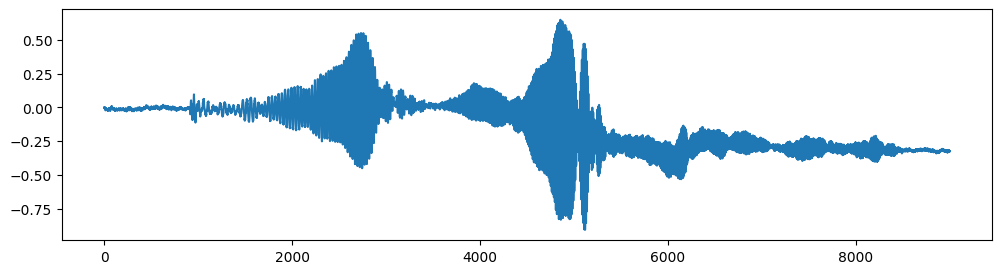

In [22]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(shifts[50, :, 1])
plt.show()

## Inspect Mask Areas

In [10]:
repo_id = 'eturok-weizmann/vibrations'
ds = load_dataset(repo_id, split='train')
snapshot_dir = snapshot_download(repo_id, repo_type="dataset", allow_patterns="data/sample_*.npz")

README.md:   0%|          | 0.00/747 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/206M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/450 [00:00<?, ? examples/s]

Fetching 450 files:   0%|          | 0/450 [00:00<?, ?it/s]

/var/folders/f6/vzqh7ynx4n3ft_sx36yv3gbm0000gn/T/ipykernel_57459/4014377561.py:18: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  is_outlier = np.abs(stats.zscore(vals)) > 2.5


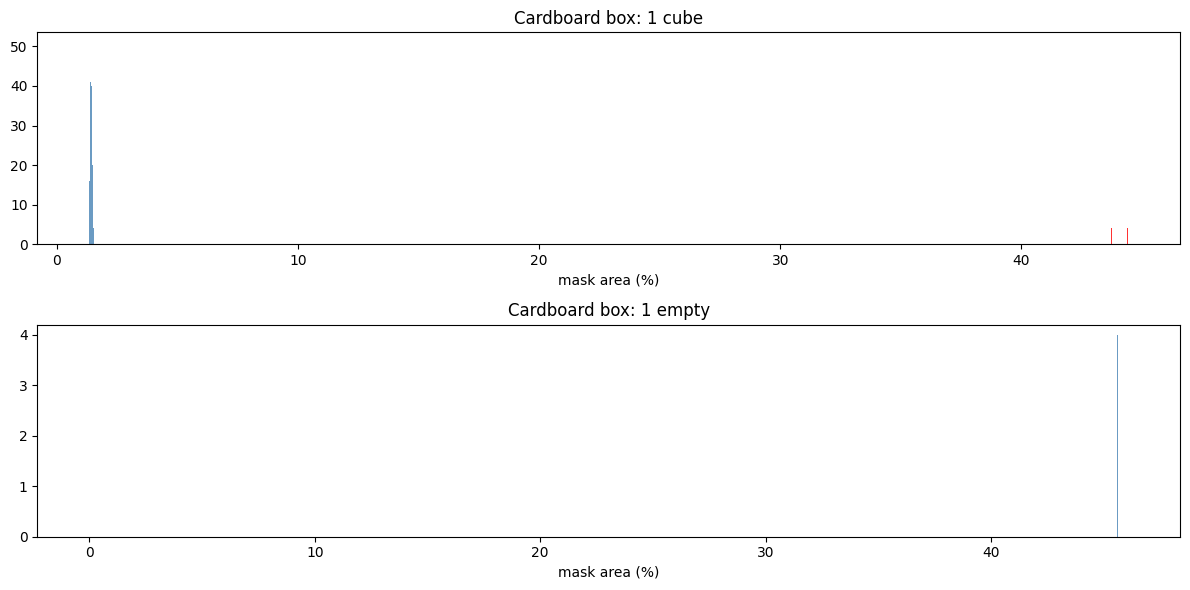

In [28]:
import pandas as pd
from scipy import stats
from PIL import Image
import matplotlib.pyplot as plt

df = pd.DataFrame({'box_material': ds['box_material'], 'object': ds['object'], 'n_objects': ds['n_objects'],
                   'mask_area': ds['mask_area'], 'sample_idx': ds['sample_idx'],
                   'hf_idx': range(len(ds))})

def pluralize(word: str, count: int) -> str: return word if count == 1 else word + 's'

# --- histograms ---
groups = df.groupby(['box_material', 'n_objects', 'object'])
n_groups = len(groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(12, 3 * n_groups))
for ax, ((mat, n_obj, obj), grp) in zip(np.array(axes).flatten(), groups):
    vals = grp['mask_area'].values
    is_outlier = np.abs(stats.zscore(vals)) > 2.5
    ax.hist(vals[~is_outlier], bins=20, color='steelblue', alpha=0.8)
    ax.hist(vals[is_outlier], bins=20, color='red', alpha=0.8)
    ax.set_title(f'{mat.capitalize()} box: {n_obj} {pluralize(obj, n_obj)}')
    ax.set_xlabel('mask area (%)')
plt.tight_layout()
plt.show()


[1 cube, cardboard box]
hf_idx=52  sample_idx=52  area=43.7%  mean=2.2%  deviation=+41.5%


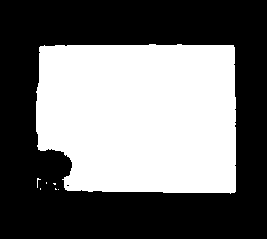

[1 cube, cardboard box]
hf_idx=53  sample_idx=53  area=43.7%  mean=2.2%  deviation=+41.5%


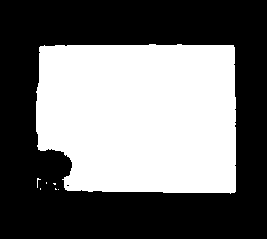

[1 cube, cardboard box]
hf_idx=54  sample_idx=54  area=43.7%  mean=2.2%  deviation=+41.5%


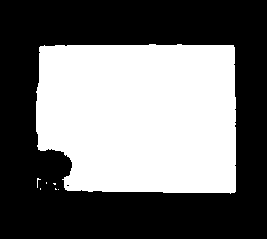

[1 cube, cardboard box]
hf_idx=55  sample_idx=55  area=43.7%  mean=2.2%  deviation=+41.5%


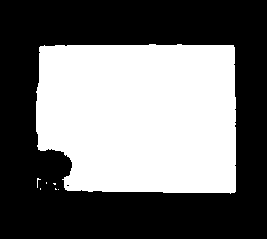

[1 cube, cardboard box]
hf_idx=60  sample_idx=60  area=44.4%  mean=2.2%  deviation=+42.2%


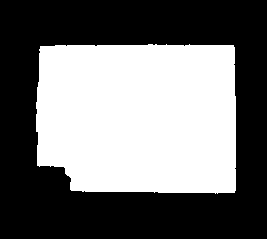

[1 cube, cardboard box]
hf_idx=61  sample_idx=61  area=44.4%  mean=2.2%  deviation=+42.2%


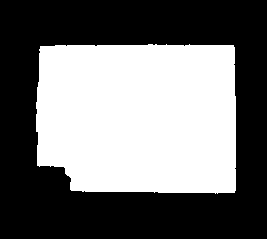

[1 cube, cardboard box]
hf_idx=62  sample_idx=62  area=44.4%  mean=2.2%  deviation=+42.2%


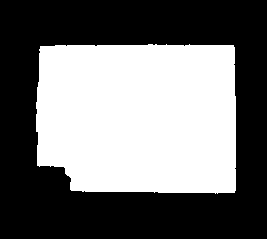

[1 cube, cardboard box]
hf_idx=63  sample_idx=63  area=44.4%  mean=2.2%  deviation=+42.2%


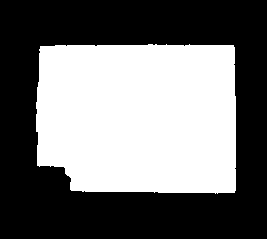

/var/folders/f6/vzqh7ynx4n3ft_sx36yv3gbm0000gn/T/ipykernel_57459/3345803712.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  outliers = grp[np.abs(stats.zscore(vals)) > 2.5]


In [30]:
# --- print outlier indices and show their masks ---
for (mat, n_obj, obj), grp in groups:
    vals = grp['mask_area'].values
    mean_area = vals.mean()
    outliers = grp[np.abs(stats.zscore(vals)) > 2.5]
    for _, row in outliers.iterrows():
        mask = np.load(os.path.join(snapshot_dir, f"data/sample_{row['sample_idx']}.npz"))['mask']
        label = f"{n_obj} {pluralize(obj, n_obj)}, {mat} box"
        print(
            f"[{label}]\n"
            f"hf_idx={int(row['hf_idx'])}  sample_idx={int(row['sample_idx'])}  "
            f"area={row['mask_area']:.1f}%  mean={mean_area:.1f}%  "
            f"deviation={row['mask_area'] - mean_area:+.1f}%"
        )
        img = Image.fromarray((mask * 255).astype(np.uint8))
        w, h = img.size
        display(img.resize((w // 4, h // 4), Image.NEAREST))

## Rerun Segmentation

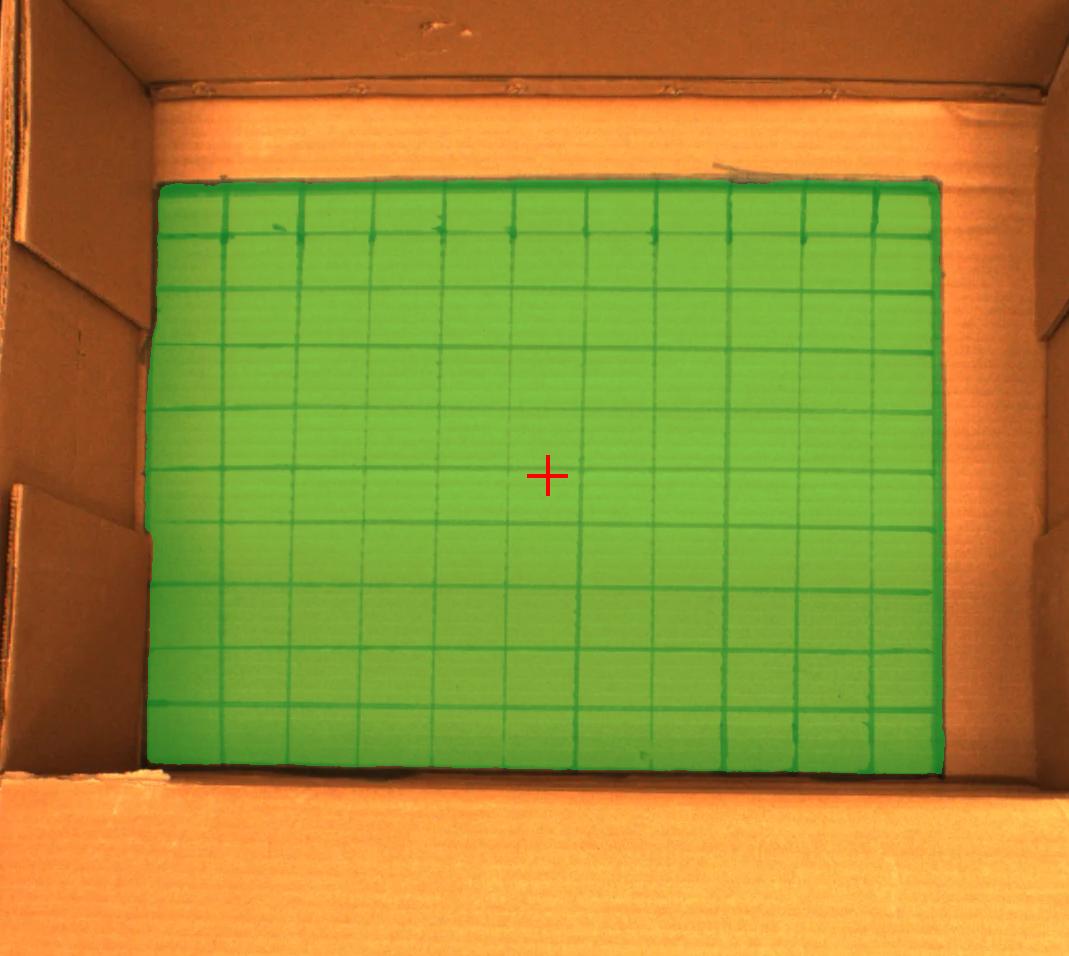

x_position: 547.23, y_position: 475.53


In [38]:
import sys
sys.path.insert(0, "..")
from utils.segment import segment_sample, PROMPT
from PIL import Image as PILImage

hf_idx = 0
row = ds[hf_idx]
exp_config = json.loads(row["experiment_config"])

raw_image = PILImage.fromarray(np.array(row["raw_image"].convert("RGB"), dtype=np.uint8))
prompt = PROMPT  # override here if needed, e.g. prompt = "A red sphere on a white table."

mask, vision = segment_sample(
    raw_image=raw_image,
    left=0.15,
    right=0.67,
    up=0.08,
    down=0.7,
    object=exp_config["object"],
    box_material=exp_config["box_material"],
    prompt=prompt,
)

display(vision["overlay_image"])
print(f"x_position: {vision['x_position']:.2f}, y_position: {vision['y_position']:.2f}")